In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report, roc_curve, auc

# Model selection and feature selection
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2

# Progress bar
from tqdm.notebook import tqdm
import time


In [135]:
x_train_scaled = pd.read_csv("data/x_train_scaled.csv").sort_values(by="video_id", ascending=True)
x_test_scaled = pd.read_csv("data/x_test_scaled.csv").sort_values(by="video_id", ascending=True)

x_train_unscaled = pd.read_csv("data/x_train_unscaled.csv").sort_values(by="video_id", ascending=True)
x_test_unscaled = pd.read_csv("data/x_test_unscaled.csv").sort_values(by="video_id", ascending=True)

y_train = pd.read_csv("data/train_y.csv").sort_values(by="video_id", ascending=True)
y_test = pd.read_csv("data/test_y.csv").sort_values(by="video_id", ascending=True)



CONVERTING CONTINUOUS Y TO BINARY LABELS

📊 Label Conversion Summary:
   Threshold: 0.8
   Label column: label

📊 Training Set Distribution:
   Class 0 (Low, < 0.8): 51 samples (36.4%)
   Class 1 (High, >= 0.8): 89 samples (63.6%)

📊 Test Set Distribution:
   Class 0 (Low, < 0.8): 21 samples (50.0%)
   Class 1 (High, >= 0.8): 21 samples (50.0%)


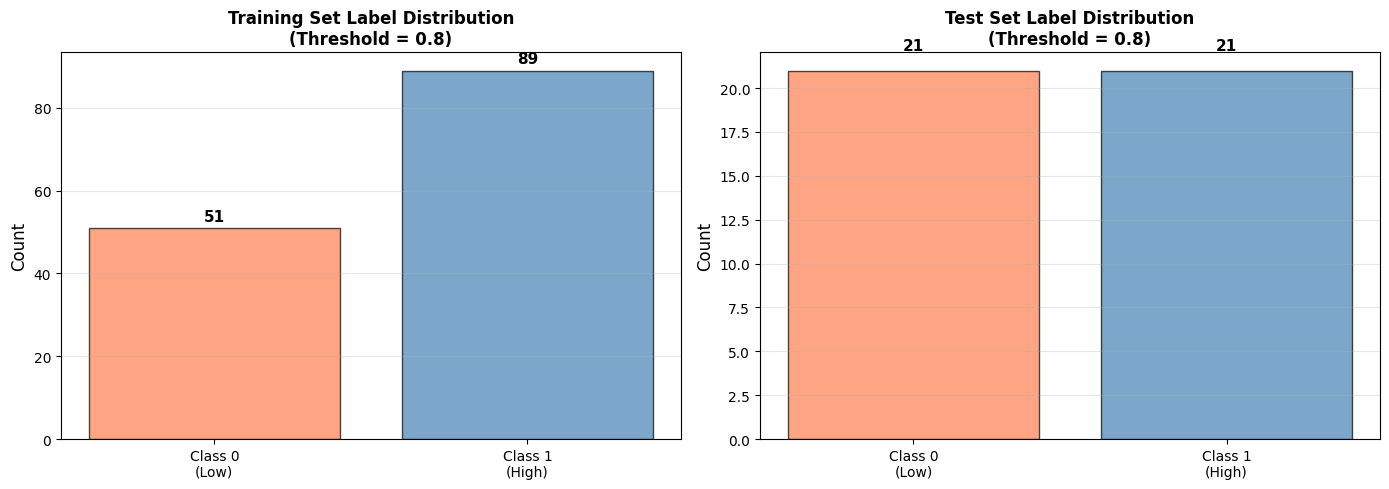


✅ Binary labels created successfully!


In [136]:
# ============================================================================
# CONVERT CONTINUOUS Y TO BINARY LABELS
# ============================================================================
# Convert continuous understandability score to binary classification
# Threshold: >= 0.8 = 1 (High understandability), < 0.8 = 0 (Low understandability)
# ============================================================================

print("=" * 80)
print("CONVERTING CONTINUOUS Y TO BINARY LABELS")
print("=" * 80)

threshold = 0.8

def convert_to_label(y, threshold=0.8):
    """Convert continuous value to binary label"""
    return 1 if y >= threshold else 0

# Get label column name
label_col = y_train.columns[1] if 'video_id' in y_train.columns else y_train.columns[0]

# Convert to binary labels
y_train_binary = y_train[label_col].apply(lambda x: convert_to_label(x, threshold))
y_test_binary = y_test[label_col].apply(lambda x: convert_to_label(x, threshold))

print(f"\n📊 Label Conversion Summary:")
print(f"   Threshold: {threshold}")
print(f"   Label column: {label_col}")

print(f"\n📊 Training Set Distribution:")
train_dist = y_train_binary.value_counts().sort_index()
print(f"   Class 0 (Low, < {threshold}): {train_dist.get(0, 0)} samples ({train_dist.get(0, 0)/len(y_train_binary)*100:.1f}%)")
print(f"   Class 1 (High, >= {threshold}): {train_dist.get(1, 0)} samples ({train_dist.get(1, 0)/len(y_train_binary)*100:.1f}%)")

print(f"\n📊 Test Set Distribution:")
test_dist = y_test_binary.value_counts().sort_index()
print(f"   Class 0 (Low, < {threshold}): {test_dist.get(0, 0)} samples ({test_dist.get(0, 0)/len(y_test_binary)*100:.1f}%)")
print(f"   Class 1 (High, >= {threshold}): {test_dist.get(1, 0)} samples ({test_dist.get(1, 0)/len(y_test_binary)*100:.1f}%)")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].bar(['Class 0\n(Low)', 'Class 1\n(High)'], 
            [train_dist.get(0, 0), train_dist.get(1, 0)],
            color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Training Set Label Distribution\n(Threshold = {threshold})', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([train_dist.get(0, 0), train_dist.get(1, 0)]):
    axes[0].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Test set
axes[1].bar(['Class 0\n(Low)', 'Class 1\n(High)'], 
            [test_dist.get(0, 0), test_dist.get(1, 0)],
            color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Test Set Label Distribution\n(Threshold = {threshold})', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([test_dist.get(0, 0), test_dist.get(1, 0)]):
    axes[1].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Binary labels created successfully!")
print("=" * 80)

In [137]:
# ============================================================================
# DATA PREPARATION
# ============================================================================
# Align X and y data, prepare features for model training
# ============================================================================

print("=" * 80)
print("DATA PREPARATION")
print("=" * 80)

# Step 1: Align data by video_id
print("\n📊 Step 1: Aligning data by video_id...")

# Get video_ids from each dataset
train_video_ids_x = set(x_train_scaled['video_id'].unique())
test_video_ids_x = set(x_test_scaled['video_id'].unique())
train_video_ids_y = set(y_train['video_id'].unique())
test_video_ids_y = set(y_test['video_id'].unique())

# Find common video_ids
train_common = sorted(list(train_video_ids_x & train_video_ids_y))
test_common = sorted(list(test_video_ids_x & test_video_ids_y))

print(f"   Train: {len(train_common)} common video_ids")
print(f"   Test: {len(test_common)} common video_ids")

# Filter to only common video_ids
x_train_aligned = x_train_scaled[x_train_scaled['video_id'].isin(train_common)].sort_values('video_id').reset_index(drop=True)
x_test_aligned = x_test_scaled[x_test_scaled['video_id'].isin(test_common)].sort_values('video_id').reset_index(drop=True)
y_train_aligned = y_train[y_train['video_id'].isin(train_common)].sort_values('video_id').reset_index(drop=True)
y_test_aligned = y_test[y_test['video_id'].isin(test_common)].sort_values('video_id').reset_index(drop=True)

# Step 2: Prepare features and labels
print("\n📊 Step 2: Preparing features and labels...")

# Remove video_id from features
X_train = x_train_aligned.drop(columns=['video_id']).values
X_test = x_test_aligned.drop(columns=['video_id']).values

# Get binary labels (aligned)
label_col = y_train.columns[1] if 'video_id' in y_train.columns else y_train.columns[0]
y_train_binary_df = pd.DataFrame({
    'video_id': y_train['video_id'].values,
    'label': y_train_binary.values
})
y_test_binary_df = pd.DataFrame({
    'video_id': y_test['video_id'].values,
    'label': y_test_binary.values
})

y_train_binary_aligned = y_train_binary_df[y_train_binary_df['video_id'].isin(train_common)].sort_values('video_id')['label'].values
y_test_binary_aligned = y_test_binary_df[y_test_binary_df['video_id'].isin(test_common)].sort_values('video_id')['label'].values

# Verify alignment
print(f"\n✅ Verification:")
print(f"   X_train shape: {X_train.shape} (samples: {X_train.shape[0]}, features: {X_train.shape[1]})")
print(f"   y_train shape: {y_train_binary_aligned.shape} (samples: {len(y_train_binary_aligned)})")
print(f"   X_test shape: {X_test.shape} (samples: {X_test.shape[0]}, features: {X_test.shape[1]})")
print(f"   y_test shape: {y_test_binary_aligned.shape} (samples: {len(y_test_binary_aligned)})")

if X_train.shape[0] != len(y_train_binary_aligned):
    raise ValueError(f"❌ MISMATCH: X_train has {X_train.shape[0]} samples but y_train has {len(y_train_binary_aligned)} samples!")
if X_test.shape[0] != len(y_test_binary_aligned):
    raise ValueError(f"❌ MISMATCH: X_test has {X_test.shape[0]} samples but y_test has {len(y_test_binary_aligned)} samples!")

# Get feature names for later use
feature_names = x_train_aligned.drop(columns=['video_id']).columns.tolist()

print(f"\n✅ Data prepared successfully!")
print(f"   Features: {len(feature_names)}")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print("=" * 80)

DATA PREPARATION

📊 Step 1: Aligning data by video_id...
   Train: 140 common video_ids
   Test: 42 common video_ids

📊 Step 2: Preparing features and labels...

✅ Verification:
   X_train shape: (140, 31) (samples: 140, features: 31)
   y_train shape: (140,) (samples: 140)
   X_test shape: (42, 31) (samples: 42, features: 31)
   y_test shape: (42,) (samples: 42)

✅ Data prepared successfully!
   Features: 31
   Training samples: 140
   Test samples: 42


## Logistc Regression

In [138]:
# ============================================================================
# BASELINE MODEL: Simple Logistic Regression (No Feature Selection)
# ============================================================================
# Evaluate baseline performance before feature selection and hyperparameter tuning
# ============================================================================

print("=" * 80)
print("BASELINE MODEL EVALUATION")
print("=" * 80)

# Define baseline model
baseline_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Perform stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(baseline_model, X_train, y_train_binary_aligned, cv=cv, scoring='accuracy')

print(f"\n📊 Baseline Logistic Regression (No Feature Selection, Default Parameters):")
print(f"   Cross-validation scores: {cv_scores}")
print(f"   Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train on full training set for baseline comparison
baseline_model.fit(X_train, y_train_binary_aligned)
baseline_train_acc = accuracy_score(y_train_binary_aligned, baseline_model.predict(X_train))
baseline_test_acc = accuracy_score(y_test_binary_aligned, baseline_model.predict(X_test))

print(f"\n📊 Baseline Performance on Full Dataset:")
print(f"   Train Accuracy: {baseline_train_acc:.4f}")
print(f"   Test Accuracy: {baseline_test_acc:.4f}")

print("\n" + "=" * 80)


BASELINE MODEL EVALUATION

📊 Baseline Logistic Regression (No Feature Selection, Default Parameters):
   Cross-validation scores: [0.5        0.67857143 0.67857143 0.57142857 0.67857143]
   Mean CV accuracy: 0.6214 (+/- 0.1471)

📊 Baseline Performance on Full Dataset:
   Train Accuracy: 0.7143
   Test Accuracy: 0.4762



In [139]:
# ============================================================================
# LOGISTIC REGRESSION: Feature Selection + Hyperparameter Tuning
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# ============================================================================

print("=" * 80)
print("LOGISTIC REGRESSION: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Create pipeline with feature selection and Logistic Regression
pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif)),
    ('classification', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

# Parameter grid for optimization
param_grid = {
    'feature_selection__k': [5, 10, 15, 20, 25, 30, 35, 40, 50],
    'classification__C': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500],
    'classification__penalty': ['l1', 'l2'],
    'classification__class_weight': [None, 'balanced'],
    'classification__fit_intercept': [True, False]
}

# Stratified K-Fold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate total parameter combinations
total_combinations = (len(param_grid['feature_selection__k']) * 
                     len(param_grid['classification__C']) * 
                     len(param_grid['classification__penalty']) *
                     len(param_grid['classification__class_weight']) *
                     len(param_grid['classification__fit_intercept']))

print(f"\n🚀 Starting GridSearchCV optimization...")
print(f"   Feature selection k values: {len(param_grid['feature_selection__k'])} options")
print(f"   Regularization C values: {len(param_grid['classification__C'])} options")
print(f"   Penalty types: {len(param_grid['classification__penalty'])} options")
print(f"   Class weights: {len(param_grid['classification__class_weight'])} options")
print(f"   Fit intercept: {len(param_grid['classification__fit_intercept'])} options")
print(f"   Total parameter combinations: {total_combinations}")
print(f"   With 5-fold CV: {total_combinations * 5} model fits")
print("=" * 80)

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPUs
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train_binary_aligned)

# Get best model
best_model = grid_search.best_estimator_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and score
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score: {grid_search.best_score_:.4f}")

# Get selected features
selected_features_mask = best_model.named_steps['feature_selection'].get_support()
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask[i]]
n_selected_features = len(selected_features)

print(f"\n📋 Selected Features: {n_selected_features} out of {len(feature_names)}")
print("=" * 80)

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Get probabilities for AUC
try:
    y_train_proba = best_model.predict_proba(X_train)[:, 1]
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    train_auc = roc_auc_score(y_train_binary_aligned, y_train_proba)
    test_auc = roc_auc_score(y_test_binary_aligned, y_test_proba)
except:
    train_auc = None
    test_auc = None

# Calculate all metrics
train_acc = accuracy_score(y_train_binary_aligned, y_train_pred)
test_acc = accuracy_score(y_test_binary_aligned, y_test_pred)
train_precision = precision_score(y_train_binary_aligned, y_train_pred, average='weighted', zero_division=0)
test_precision = precision_score(y_test_binary_aligned, y_test_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train_binary_aligned, y_train_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test_binary_aligned, y_test_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train_binary_aligned, y_train_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test_binary_aligned, y_test_pred, average='weighted', zero_division=0)

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_acc:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1 Score:  {train_f1:.4f}")
if train_auc is not None:
    print(f"   AUC-ROC:   {train_auc:.4f}")

print(f"\n📊 Test Set Performance:")
print(f"   Accuracy:  {test_acc:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1 Score:  {test_f1:.4f}")
if test_auc is not None:
    print(f"   AUC-ROC:   {test_auc:.4f}")

print("\n" + "=" * 80)


LOGISTIC REGRESSION: Feature Selection + Hyperparameter Tuning

🚀 Starting GridSearchCV optimization...
   Feature selection k values: 9 options
   Regularization C values: 12 options
   Penalty types: 2 options
   Class weights: 2 options
   Fit intercept: 2 options
   Total parameter combinations: 864
   With 5-fold CV: 4320 model fits
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

OPTIMIZATION COMPLETE!

🏆 Best Parameters:
   classification__C: 50
   classification__class_weight: None
   classification__fit_intercept: True
   classification__penalty: l2
   feature_selection__k: 10

📊 Best CV Score: 0.6429

📋 Selected Features: 10 out of 31

MODEL PERFORMANCE

📊 Training Set Performance:
   Accuracy:  0.6714
   Precision: 0.6621
   Recall:    0.6714
   F1 Score:  0.6645
   AUC-ROC:   0.7306

📊 Test Set Performance:
   Accuracy:  0.5000
   Precision: 0.5000
   Recall:    0.5000
   F1 Score:  0.4470
   AUC-ROC:   0.5986



VISUALIZATION AND DETAILED ANALYSIS

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.50      0.19      0.28        21
        High       0.50      0.81      0.62        21

    accuracy                           0.50        42
   macro avg       0.50      0.50      0.45        42
weighted avg       0.50      0.50      0.45        42



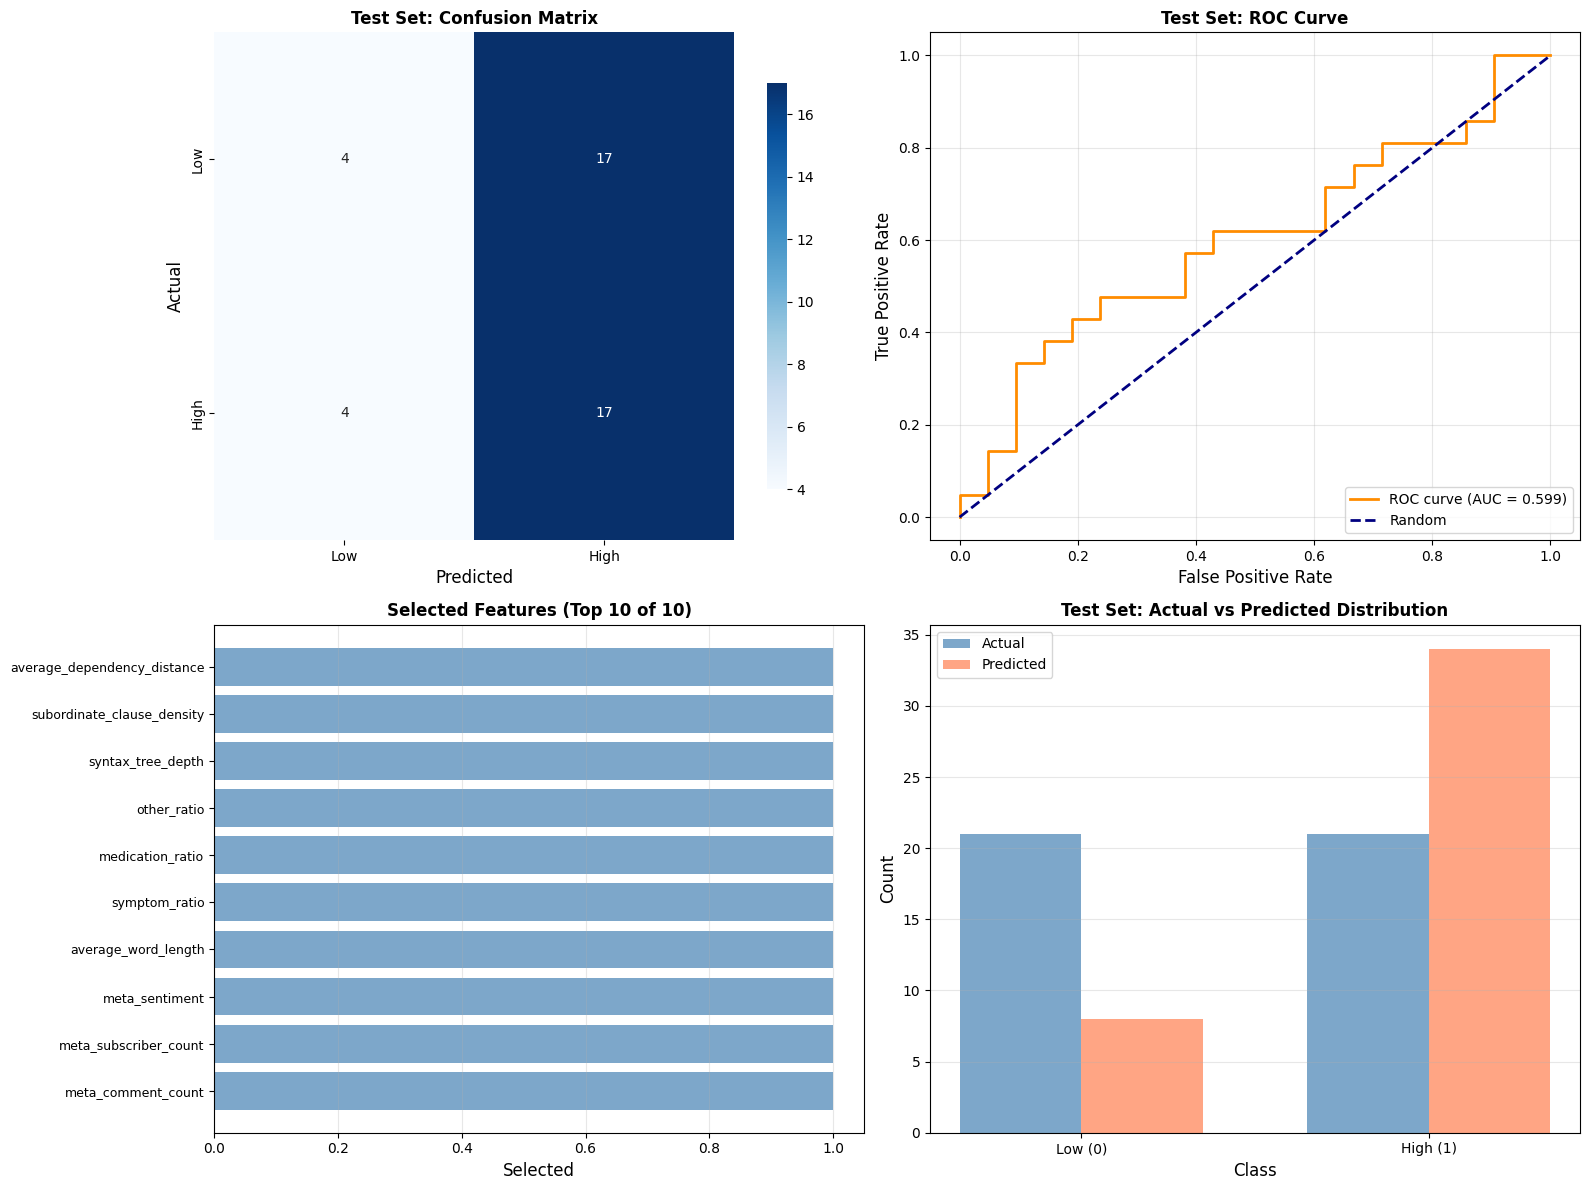


📋 All Selected Features (10):
    1. meta_comment_count
    2. meta_subscriber_count
    3. meta_sentiment
    4. average_word_length
    5. symptom_ratio
    6. medication_ratio
    7. other_ratio
    8. syntax_tree_depth
    9. subordinate_clause_density
   10. average_dependency_distance



In [140]:
# ============================================================================
# VISUALIZATION AND DETAILED ANALYSIS
# ============================================================================

print("=" * 80)
print("VISUALIZATION AND DETAILED ANALYSIS")
print("=" * 80)

# Confusion Matrix
cm_test = confusion_matrix(y_test_binary_aligned, y_test_pred)

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(y_test_binary_aligned, y_test_pred, target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if y_test_proba is not None:
    fpr, tpr, _ = roc_curve(y_test_binary_aligned, y_test_proba)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Selected Features (Top 15)
ax3 = axes[1, 0]
if len(selected_features) > 0:
    features_to_show = selected_features[:15] if len(selected_features) > 15 else selected_features
    ax3.barh(range(len(features_to_show)), [1] * len(features_to_show), color='steelblue', alpha=0.7)
    ax3.set_yticks(range(len(features_to_show)))
    ax3.set_yticklabels([f[:30] for f in features_to_show], fontsize=9)
    ax3.set_xlabel('Selected', fontsize=12)
    ax3.set_title(f'Selected Features (Top {len(features_to_show)} of {len(selected_features)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    if len(selected_features) > 15:
        ax3.text(0.5, -0.15, f'... and {len(selected_features) - 15} more features', 
                ha='center', transform=ax3.transAxes, fontsize=9, style='italic')
else:
    ax3.text(0.5, 0.5, 'No features selected', 
            ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Selected Features', fontsize=12, fontweight='bold')

# Plot 4: Prediction Distribution
ax4 = axes[1, 1]
unique_actual, counts_actual = np.unique(y_test_binary_aligned, return_counts=True)
x_pos = np.arange(len(unique_actual))
width = 0.35
ax4.bar(x_pos - width/2, counts_actual, width, label='Actual', color='steelblue', alpha=0.7)
pred_counts = np.zeros(len(unique_actual))
for i, cls in enumerate(unique_actual):
    pred_counts[i] = np.sum(y_test_pred == cls)
ax4.bar(x_pos + width/2, pred_counts, width, label='Predicted', color='coral', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['Low (0)', 'High (1)'], fontsize=10)
ax4.set_ylabel('Count', fontsize=12)
ax4.set_xlabel('Class', fontsize=12)
ax4.set_title('Test Set: Actual vs Predicted Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features)}):")
print("=" * 80)
for i, feat in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)


## Decision Tree

In [165]:
# ============================================================================
# DECISION TREE: Feature Selection + Hyperparameter Tuning (Anti-Overfitting)
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# Focus on preventing overfitting with max_depth, min_samples_split, etc.
# ============================================================================

print("=" * 80)
print("DECISION TREE: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Create pipeline with feature selection and Decision Tree
dt_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif)),
    ('classification', DecisionTreeClassifier(random_state=42))
])

# Parameter grid for optimization (focus on preventing overfitting)
param_grid_dt = {
    'feature_selection__k': [5, 10, 15, 20, 25, 30],
    'classification__max_depth': [3, 5, 7, 10, 15, 20, None],  # Limit depth to prevent overfitting
    'classification__min_samples_split': [2, 5, 10, 20, 30, 50],  # Minimum samples to split
    'classification__min_samples_leaf': [1, 2, 4, 5, 10, 15, 20],  # Minimum samples in leaf
    'classification__max_features': ['sqrt', 'log2', None, 0.5, 0.7],  # Limit features per split
    'classification__criterion': ['gini', 'entropy'],  # Splitting criterion
    'classification__class_weight': [None, 'balanced'],  # Handle class imbalance
    'classification__min_impurity_decrease': [0.0, 0.001, 0.01, 0.1]  # Minimum impurity decrease
}

# Stratified K-Fold for cross-validation
cv_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate total parameter combinations
total_combinations_dt = (len(param_grid_dt['feature_selection__k']) * 
                         len(param_grid_dt['classification__max_depth']) * 
                         len(param_grid_dt['classification__min_samples_split']) *
                         len(param_grid_dt['classification__min_samples_leaf']) *
                         len(param_grid_dt['classification__max_features']) *
                         len(param_grid_dt['classification__criterion']) *
                         len(param_grid_dt['classification__class_weight']) *
                         len(param_grid_dt['classification__min_impurity_decrease']))

print(f"\n🚀 Starting GridSearchCV optimization for Decision Tree...")
print(f"   Feature selection k values: {len(param_grid_dt['feature_selection__k'])} options")
print(f"   Max depth: {len(param_grid_dt['classification__max_depth'])} options (including None)")
print(f"   Min samples split: {len(param_grid_dt['classification__min_samples_split'])} options")
print(f"   Min samples leaf: {len(param_grid_dt['classification__min_samples_leaf'])} options")
print(f"   Max features: {len(param_grid_dt['classification__max_features'])} options")
print(f"   Criterion: {len(param_grid_dt['classification__criterion'])} options")
print(f"   Class weight: {len(param_grid_dt['classification__class_weight'])} options")
print(f"   Min impurity decrease: {len(param_grid_dt['classification__min_impurity_decrease'])} options")
print(f"   Total parameter combinations: {total_combinations_dt}")
print(f"   With 5-fold CV: {total_combinations_dt * 5} model fits")
print("=" * 80)

# Grid search
grid_search_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=cv_dt,
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPUs
    verbose=1
)

# Fit grid search
grid_search_dt.fit(X_train, y_train_binary_aligned)

# Get best parameters from GridSearchCV
best_params_dt = grid_search_dt.best_params_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and CV score
print(f"\n🏆 Best Parameters (from GridSearchCV):")
for param, value in best_params_dt.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score: {grid_search_dt.best_score_:.4f}")

# ============================================================================
# RETRAIN ON FULL TRAINING SET WITH BEST PARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

print("\n🔄 Retraining model on FULL training set with best parameters...")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Features: {X_train.shape[1]}")

# Create a new pipeline with best parameters
best_pipeline_dt = Pipeline([
    ('feature_selection', SelectKBest(f_classif, k=best_params_dt['feature_selection__k'])),
    ('classification', DecisionTreeClassifier(
        max_depth=best_params_dt['classification__max_depth'],
        min_samples_split=best_params_dt['classification__min_samples_split'],
        min_samples_leaf=best_params_dt['classification__min_samples_leaf'],
        max_features=best_params_dt['classification__max_features'],
        criterion=best_params_dt['classification__criterion'],
        class_weight=best_params_dt['classification__class_weight'],
        min_impurity_decrease=best_params_dt['classification__min_impurity_decrease'],
        random_state=42
    ))
])

# Retrain on FULL training set
best_pipeline_dt.fit(X_train, y_train_binary_aligned)

# Use this as the final model
best_model_dt = best_pipeline_dt

print("✅ Model retrained on FULL training set!")
print("=" * 80)

# Get selected features
selected_features_mask_dt = best_model_dt.named_steps['feature_selection'].get_support()
selected_features_dt = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask_dt[i]]
n_selected_features_dt = len(selected_features_dt)

print(f"\n📋 Selected Features: {n_selected_features_dt} out of {len(feature_names)}")

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

print(f"\n📊 Test Set Information:")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Features: {X_test.shape[1]}")

# Display tree complexity info
best_dt = best_model_dt.named_steps['classification']
print(f"\n🌳 Tree Complexity:")
print(f"   Max depth: {best_dt.max_depth if best_dt.max_depth else 'Unlimited'}")
print(f"   Min samples split: {best_dt.min_samples_split}")
print(f"   Min samples leaf: {best_dt.min_samples_leaf}")
print(f"   Max features: {best_dt.max_features}")
print(f"   Number of leaves: {best_dt.get_n_leaves()}")
print(f"   Tree depth: {best_dt.get_depth()}")

print("=" * 80)

# ============================================================================
# FINAL EVALUATION: Make predictions on test set
# ============================================================================
print("\n🔍 Making predictions on test set with retrained model...")

# Make predictions on training set (for comparison)
y_train_pred_dt = best_model_dt.predict(X_train)

# Make predictions on TEST SET (final evaluation)
y_test_pred_dt = best_model_dt.predict(X_test)

print("✅ Predictions completed!")
print(f"   Training predictions: {len(y_train_pred_dt)} samples")
print(f"   Test predictions: {len(y_test_pred_dt)} samples")

# Get probabilities for AUC
try:
    y_train_proba_dt = best_model_dt.predict_proba(X_train)[:, 1]
    y_test_proba_dt = best_model_dt.predict_proba(X_test)[:, 1]
    train_auc_dt = roc_auc_score(y_train_binary_aligned, y_train_proba_dt)
    test_auc_dt = roc_auc_score(y_test_binary_aligned, y_test_proba_dt)
except:
    train_auc_dt = None
    test_auc_dt = None

# Calculate all metrics
train_acc_dt = accuracy_score(y_train_binary_aligned, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test_binary_aligned, y_test_pred_dt)
train_precision_dt = precision_score(y_train_binary_aligned, y_train_pred_dt, average='weighted', zero_division=0)
test_precision_dt = precision_score(y_test_binary_aligned, y_test_pred_dt, average='weighted', zero_division=0)
train_recall_dt = recall_score(y_train_binary_aligned, y_train_pred_dt, average='weighted', zero_division=0)
test_recall_dt = recall_score(y_test_binary_aligned, y_test_pred_dt, average='weighted', zero_division=0)
train_f1_dt = f1_score(y_train_binary_aligned, y_train_pred_dt, average='weighted', zero_division=0)
test_f1_dt = f1_score(y_test_binary_aligned, y_test_pred_dt, average='weighted', zero_division=0)

# Check for overfitting (difference between train and test accuracy)
overfitting_gap = train_acc_dt - test_acc_dt

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_acc_dt:.4f}")
print(f"   Precision: {train_precision_dt:.4f}")
print(f"   Recall:    {train_recall_dt:.4f}")
print(f"   F1 Score:  {train_f1_dt:.4f}")
if train_auc_dt is not None:
    print(f"   AUC-ROC:   {train_auc_dt:.4f}")

print(f"\n📊 Test Set Performance (FINAL EVALUATION):")
print(f"   ✅ Final Test Accuracy:  {test_acc_dt:.4f}")
print(f"   ✅ Final Test Precision: {test_precision_dt:.4f}")
print(f"   ✅ Final Test Recall:    {test_recall_dt:.4f}")
print(f"   ✅ Final Test F1 Score:  {test_f1_dt:.4f}")
if test_auc_dt is not None:
    print(f"   ✅ Final Test AUC-ROC:   {test_auc_dt:.4f}")
print(f"\n   📝 Note: This is the performance on the test set using the model")
print(f"      trained on the FULL training set with best parameters.")

print(f"\n⚠️  Overfitting Check:")
print(f"   Train-Test Accuracy Gap: {overfitting_gap:.4f}")
if overfitting_gap > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
elif overfitting_gap > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
else:
    print(f"   ✅ Good: Gap is acceptable.")

print("\n" + "=" * 80)


DECISION TREE: Feature Selection + Hyperparameter Tuning

🚀 Starting GridSearchCV optimization for Decision Tree...
   Feature selection k values: 6 options
   Max depth: 7 options (including None)
   Min samples split: 6 options
   Min samples leaf: 7 options
   Max features: 5 options
   Criterion: 2 options
   Class weight: 2 options
   Min impurity decrease: 4 options
   Total parameter combinations: 141120
   With 5-fold CV: 705600 model fits
Fitting 5 folds for each of 141120 candidates, totalling 705600 fits

OPTIMIZATION COMPLETE!

🏆 Best Parameters (from GridSearchCV):
   classification__class_weight: None
   classification__criterion: entropy
   classification__max_depth: 5
   classification__max_features: sqrt
   classification__min_impurity_decrease: 0.01
   classification__min_samples_leaf: 5
   classification__min_samples_split: 30
   feature_selection__k: 15

📊 Best CV Score: 0.6714

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Retraining model on FULL trainin

DECISION TREE: Visualization and Detailed Analysis

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.73      0.38      0.50        21
        High       0.58      0.86      0.69        21

    accuracy                           0.62        42
   macro avg       0.65      0.62      0.60        42
weighted avg       0.65      0.62      0.60        42



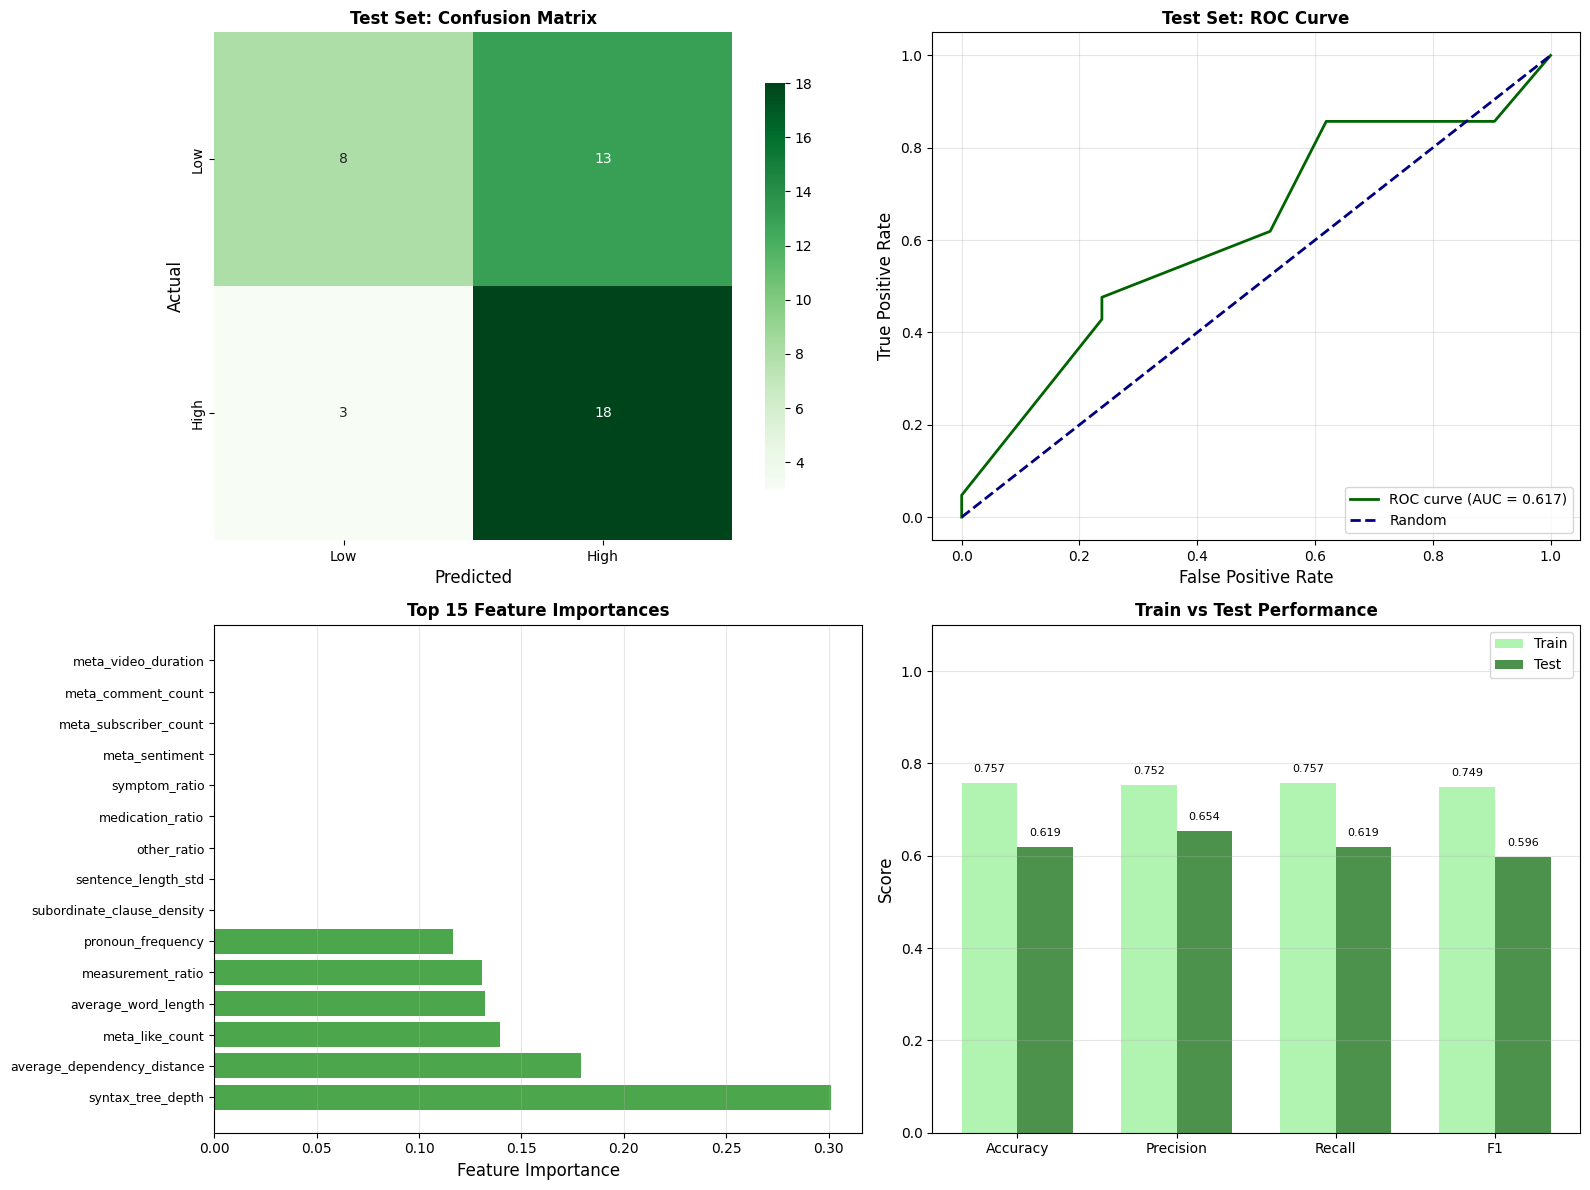


📋 All Selected Features (15):
    1. meta_video_duration
    2. meta_like_count
    3. meta_comment_count
    4. meta_subscriber_count
    5. meta_sentiment
    6. average_word_length
    7. symptom_ratio
    8. medication_ratio
    9. measurement_ratio
   10. other_ratio
   11. sentence_length_std
   12. syntax_tree_depth
   13. subordinate_clause_density
   14. average_dependency_distance
   15. pronoun_frequency

📊 Feature Importance (Top 10):
    1. syntax_tree_depth                        : 0.3012
    2. average_dependency_distance              : 0.1793
    3. meta_like_count                          : 0.1395
    4. average_word_length                      : 0.1324
    5. measurement_ratio                        : 0.1308
    6. pronoun_frequency                        : 0.1168
    7. meta_video_duration                      : 0.0000
    8. meta_comment_count                       : 0.0000
    9. meta_subscriber_count                    : 0.0000
   10. meta_sentiment              

In [142]:
# ============================================================================
# DECISION TREE: Visualization and Detailed Analysis
# ============================================================================

print("=" * 80)
print("DECISION TREE: Visualization and Detailed Analysis")
print("=" * 80)

# Confusion Matrix
cm_test_dt = confusion_matrix(y_test_binary_aligned, y_test_pred_dt)

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(y_test_binary_aligned, y_test_pred_dt, target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test_dt, annot=True, fmt='d', cmap='Greens', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if y_test_proba_dt is not None:
    fpr_dt, tpr_dt, _ = roc_curve(y_test_binary_aligned, y_test_proba_dt)
    roc_auc_dt = auc(fpr_dt, tpr_dt)
    ax2.plot(fpr_dt, tpr_dt, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_dt:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Feature Importance (Top 15)
ax3 = axes[1, 0]
best_dt = best_model_dt.named_steps['classification']
feature_importance = best_dt.feature_importances_
# Get indices of selected features
selected_indices = [i for i in range(len(feature_names)) if selected_features_mask_dt[i]]
selected_importance = feature_importance
selected_feature_names_dt = selected_features_dt

# Sort by importance
importance_sorted_idx = np.argsort(selected_importance)[::-1]
top_n = min(15, len(selected_feature_names_dt))
top_indices = importance_sorted_idx[:top_n]

ax3.barh(range(top_n), selected_importance[top_indices], color='green', alpha=0.7)
ax3.set_yticks(range(top_n))
ax3.set_yticklabels([selected_feature_names_dt[i][:30] for i in top_indices], fontsize=9)
ax3.set_xlabel('Feature Importance', fontsize=12)
ax3.set_title(f'Top {top_n} Feature Importances', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Train vs Test Performance Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_metrics = [train_acc_dt, train_precision_dt, train_recall_dt, train_f1_dt]
test_metrics = [test_acc_dt, test_precision_dt, test_recall_dt, test_f1_dt]

x_pos = np.arange(len(metrics))
width = 0.35
ax4.bar(x_pos - width/2, train_metrics, width, label='Train', color='lightgreen', alpha=0.7)
ax4.bar(x_pos + width/2, test_metrics, width, label='Test', color='darkgreen', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_metrics, test_metrics)):
    ax4.text(i - width/2, train_val + 0.02, f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
    ax4.text(i + width/2, test_val + 0.02, f'{test_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features_dt)}):")
print("=" * 80)
for i, feat in enumerate(selected_features_dt, 1):
    print(f"   {i:2d}. {feat}")

# Display feature importance (sorted)
print(f"\n📊 Feature Importance (Top 10):")
print("=" * 80)
importance_sorted = sorted(zip(selected_feature_names_dt, selected_importance), 
                           key=lambda x: x[1], reverse=True)
for i, (feat, imp) in enumerate(importance_sorted[:10], 1):
    print(f"   {i:2d}. {feat[:40]:40s} : {imp:.4f}")

print("\n" + "=" * 80)


In [166]:
# ============================================================================
# SAVE DECISION TREE MODEL AND RESULTS
# ============================================================================

import pickle
import json
from datetime import datetime

print("=" * 80)
print("SAVING DECISION TREE MODEL AND RESULTS")
print("=" * 80)

# Verify that best_model_dt is the retrained model (not from GridSearchCV)
# best_model_dt should be trained on FULL training set with best parameters
print("\n🔍 Verifying model to save...")
if hasattr(best_model_dt, 'named_steps'):
    print("✅ Model is a Pipeline (retrained model)")
    print(f"   Model type: {type(best_model_dt).__name__}")
    print(f"   This model was trained on FULL training set ({X_train.shape[0]} samples)")
else:
    print("⚠️  WARNING: Model structure unexpected")

# Save best model (this is the model retrained on FULL training set)
model_filename_dt = "data/best_decision_tree_model.pkl"
with open(model_filename_dt, 'wb') as f:
    pickle.dump(best_model_dt, f)
print(f"\n✅ Best Decision Tree model saved to: {model_filename_dt}")
print(f"   📝 Note: This model was trained on FULL training set with best parameters")

# Get tree complexity info
best_dt = best_model_dt.named_steps['classification']

# Ensure best_params_dt exists (in case this cell is run independently)
if 'best_params_dt' not in locals():
    # Try to get from grid_search_dt if available
    try:
        best_params_dt = grid_search_dt.best_params_
        print("⚠️  Note: Using best_params from grid_search_dt (retraining cell may not have been run)")
    except NameError:
        print("⚠️  ERROR: best_params_dt not found. Please run the Decision Tree training cell first!")
        raise

# Save model metadata
metadata_dt = {
    'model_name': 'Decision Tree with Feature Selection',
    'problem_type': 'binary_classification',
    'threshold': 0.8,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'n_selected_features': len(selected_features_dt),
    'selected_features': selected_features_dt,
    'n_train_samples': X_train.shape[0],
    'n_test_samples': X_test.shape[0],
    'best_parameters': best_params_dt,
    'training_note': 'Model was retrained on FULL training set with best parameters from GridSearchCV',
    'best_cv_score': float(grid_search_dt.best_score_),
    'tree_complexity': {
        'max_depth': best_dt.max_depth if best_dt.max_depth else 'Unlimited',
        'min_samples_split': int(best_dt.min_samples_split),
        'min_samples_leaf': int(best_dt.min_samples_leaf),
        'max_features': str(best_dt.max_features),
        'n_leaves': int(best_dt.get_n_leaves()),
        'tree_depth': int(best_dt.get_depth()),
        'criterion': best_dt.criterion
    },
    'metrics': {
        'train_accuracy': float(train_acc_dt),
        'test_accuracy': float(test_acc_dt),
        'train_precision': float(train_precision_dt),
        'test_precision': float(test_precision_dt),
        'train_recall': float(train_recall_dt),
        'test_recall': float(test_recall_dt),
        'train_f1': float(train_f1_dt),
        'test_f1': float(test_f1_dt),
        'overfitting_gap': float(overfitting_gap)
    }
}

if train_auc_dt is not None:
    metadata_dt['metrics']['train_auc'] = float(train_auc_dt)
if test_auc_dt is not None:
    metadata_dt['metrics']['test_auc'] = float(test_auc_dt)

# Add feature importance (if available)
# Ensure variables exist
if 'selected_feature_names_dt' not in locals() or 'selected_importance' not in locals():
    # Get from the model if not already defined
    best_dt = best_model_dt.named_steps['classification']
    selected_importance = best_dt.feature_importances_
    selected_feature_names_dt = selected_features_dt

if len(selected_feature_names_dt) == len(selected_importance):
    feature_importance_dict = {feat: float(imp) for feat, imp in zip(selected_feature_names_dt, selected_importance)}
    metadata_dt['feature_importance'] = feature_importance_dict
else:
    print("⚠️  Warning: Feature importance arrays length mismatch, skipping feature importance in metadata")

metadata_filename_dt = "data/best_decision_tree_metadata.json"
with open(metadata_filename_dt, 'w') as f:
    json.dump(metadata_dt, f, indent=2)
print(f"✅ Decision Tree model metadata saved to: {metadata_filename_dt}")

# Save selected features with importance
selected_features_df_dt = pd.DataFrame({
    'feature_name': selected_feature_names_dt,
    'importance': selected_importance,
    'rank': range(1, len(selected_feature_names_dt) + 1)
})
selected_features_df_dt = selected_features_df_dt.sort_values('importance', ascending=False).reset_index(drop=True)
selected_features_df_dt['rank'] = range(1, len(selected_features_df_dt) + 1)
selected_features_df_dt.to_csv('data/decision_tree_selected_features.csv', index=False)
print(f"✅ Selected features with importance saved to: data/decision_tree_selected_features.csv")

print("\n" + "=" * 80)
print("DECISION TREE MODEL SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\n📝 Summary:")
print(f"   • Model file: {model_filename_dt}")
print(f"   • Metadata file: {metadata_filename_dt}")
print(f"   • Selected features: data/decision_tree_selected_features.csv")
print(f"   • Tree depth: {best_dt.get_depth()}")
print(f"   • Number of leaves: {best_dt.get_n_leaves()}")
print(f"   • Overfitting gap: {overfitting_gap:.4f}")
print("\n💡 To load the model later:")
print(f"   import pickle")
print(f"   with open('{model_filename_dt}', 'rb') as f:")
print(f"       model = pickle.load(f)")
print("=" * 80)


SAVING DECISION TREE MODEL AND RESULTS

🔍 Verifying model to save...
✅ Model is a Pipeline (retrained model)
   Model type: Pipeline
   This model was trained on FULL training set (140 samples)

✅ Best Decision Tree model saved to: data/best_decision_tree_model.pkl
   📝 Note: This model was trained on FULL training set with best parameters
✅ Decision Tree model metadata saved to: data/best_decision_tree_metadata.json
✅ Selected features with importance saved to: data/decision_tree_selected_features.csv

DECISION TREE MODEL SAVED SUCCESSFULLY!

📝 Summary:
   • Model file: data/best_decision_tree_model.pkl
   • Metadata file: data/best_decision_tree_metadata.json
   • Selected features: data/decision_tree_selected_features.csv
   • Tree depth: 5
   • Number of leaves: 8
   • Overfitting gap: 0.1381

💡 To load the model later:
   import pickle
   with open('data/best_decision_tree_model.pkl', 'rb') as f:
       model = pickle.load(f)


## SVM

In [173]:
# ============================================================================
# SVM: Feature Selection + Hyperparameter Tuning (Anti-Overfitting)
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# Focus on preventing overfitting with different kernels and regularization
# ============================================================================

print("=" * 80)
print("SVM: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Note: Need to prepare data first (run Cell 3 before this)
# Check if data is prepared
try:
    X_train_check = X_train
    y_train_check = y_train_binary_aligned
    print("✅ Data is prepared. Proceeding with SVM optimization...")
except NameError:
    print("⚠️  WARNING: Data not prepared yet. Please run Cell 3 (DATA PREPARATION) first!")
    print("   This cell will be skipped.")
    raise

# Create pipeline with feature selection and SVM
svm_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif)),
    ('classification', SVC(random_state=42, probability=True))  # probability=True for ROC-AUC
])

# Parameter grid for optimization (focus on preventing overfitting)
# Different kernels have different parameters
# NOTE: Reduced grid size for faster execution (still comprehensive)
param_grid_svm = {
    'feature_selection__k': [5, 10, 12, 15, 18, 20],
    'classification__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'classification__C': [0.01, 0.05, 0.1, 0.2, 0.5, 0.8],  # Regularization parameter (reduced from 10 to 8)
    'classification__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # For rbf, poly, sigmoid (reduced from 8 to 6)
    'classification__degree': [1, 2, 3, 4],  # For poly kernel only (reduced from 4 to 3)
    'classification__coef0': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],  # For poly and sigmoid (keep all)
    'classification__class_weight': [None, 'balanced'],  # Handle class imbalance
    'classification__shrinking': [True]  # Shrinking heuristic (only True for faster search)
}




# Stratified K-Fold for cross-validation
cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
print("\n📊 Starting optimization...")
print("   (This may take a while. Progress will be shown below.)\n")

start_time_svm = time.time()

grid_search_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=cv_svm,
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPUs
    verbose=1,  # Show progress
    return_train_score=True  # Return training scores for overfitting check
)

# Fit grid search
grid_search_svm.fit(X_train, y_train_binary_aligned)

elapsed_time_svm = time.time() - start_time_svm

print(f"\n✅ Optimization completed!")
print(f"   Total time: {elapsed_time_svm/60:.1f} minutes ({elapsed_time_svm:.1f} seconds)")

# Get best parameters from GridSearchCV
best_params_svm = grid_search_svm.best_params_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and CV score
print(f"\n🏆 Best Parameters (from GridSearchCV):")
for param, value in best_params_svm.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score: {grid_search_svm.best_score_:.4f}")

# ============================================================================
# RETRAIN ON FULL TRAINING SET WITH BEST PARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

print("\n🔄 Retraining model on FULL training set with best parameters...")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Features: {X_train.shape[1]}")

# Create a new pipeline with best parameters
best_pipeline_svm = Pipeline([
    ('feature_selection', SelectKBest(f_classif, k=best_params_svm['feature_selection__k'])),
    ('classification', SVC(
        kernel=best_params_svm['classification__kernel'],
        C=best_params_svm['classification__C'],
        gamma=best_params_svm['classification__gamma'],
        degree=best_params_svm.get('classification__degree', 3),  # Default for non-poly kernels
        coef0=best_params_svm.get('classification__coef0', 0.0),  # Default for linear/rbf
        class_weight=best_params_svm['classification__class_weight'],
        shrinking=best_params_svm['classification__shrinking'],
        random_state=42,
        probability=True
    ))
])

# Retrain on FULL training set
best_pipeline_svm.fit(X_train, y_train_binary_aligned)

# Use this as the final model
best_model_svm = best_pipeline_svm

print("✅ Model retrained on FULL training set!")
print("=" * 80)

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

print(f"\n📊 Test Set Information:")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Features: {X_test.shape[1]}")

# Get selected features
selected_features_mask_svm = best_model_svm.named_steps['feature_selection'].get_support()
selected_features_svm = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask_svm[i]]
n_selected_features_svm = len(selected_features_svm)

print(f"\n📋 Selected Features: {n_selected_features_svm} out of {len(feature_names)}")

# Display SVM info
best_svm = best_model_svm.named_steps['classification']
print(f"\n🔧 SVM Configuration:")
print(f"   Kernel: {best_svm.kernel}")
print(f"   C (regularization): {best_svm.C}")
print(f"   Gamma: {best_svm.gamma}")
if best_svm.kernel == 'poly':
    print(f"   Degree: {best_svm.degree}")
    print(f"   Coef0: {best_svm.coef0}")
elif best_svm.kernel == 'sigmoid':
    print(f"   Coef0: {best_svm.coef0}")
print(f"   Class weight: {best_svm.class_weight}")
print(f"   Shrinking: {best_svm.shrinking}")

print("=" * 80)

# ============================================================================
# FINAL EVALUATION: Make predictions on test set
# ============================================================================
print("\n🔍 Making predictions on test set with retrained model...")

# Make predictions on training set (for comparison)
y_train_pred_svm = best_model_svm.predict(X_train)

# Make predictions on TEST SET (final evaluation)
y_test_pred_svm = best_model_svm.predict(X_test)

print("✅ Predictions completed!")
print(f"   Training predictions: {len(y_train_pred_svm)} samples")
print(f"   Test predictions: {len(y_test_pred_svm)} samples")

# Get probabilities for AUC
try:
    y_train_proba_svm = best_model_svm.predict_proba(X_train)[:, 1]
    y_test_proba_svm = best_model_svm.predict_proba(X_test)[:, 1]
    train_auc_svm = roc_auc_score(y_train_binary_aligned, y_train_proba_svm)
    test_auc_svm = roc_auc_score(y_test_binary_aligned, y_test_proba_svm)
except:
    train_auc_svm = None
    test_auc_svm = None

# Calculate all metrics
train_acc_svm = accuracy_score(y_train_binary_aligned, y_train_pred_svm)
test_acc_svm = accuracy_score(y_test_binary_aligned, y_test_pred_svm)
train_precision_svm = precision_score(y_train_binary_aligned, y_train_pred_svm, average='weighted', zero_division=0)
test_precision_svm = precision_score(y_test_binary_aligned, y_test_pred_svm, average='weighted', zero_division=0)
train_recall_svm = recall_score(y_train_binary_aligned, y_train_pred_svm, average='weighted', zero_division=0)
test_recall_svm = recall_score(y_test_binary_aligned, y_test_pred_svm, average='weighted', zero_division=0)
train_f1_svm = f1_score(y_train_binary_aligned, y_train_pred_svm, average='weighted', zero_division=0)
test_f1_svm = f1_score(y_test_binary_aligned, y_test_pred_svm, average='weighted', zero_division=0)

# Check for overfitting (difference between train and test accuracy)
overfitting_gap_svm = train_acc_svm - test_acc_svm

# Check train vs test scores from CV
if 'mean_train_score' in grid_search_svm.cv_results_:
    mean_train_scores = grid_search_svm.cv_results_['mean_train_score']
    mean_test_scores = grid_search_svm.cv_results_['mean_test_score']
    best_idx = grid_search_svm.best_index_
    cv_train_score = mean_train_scores[best_idx]
    cv_test_score = mean_test_scores[best_idx]
    cv_overfitting_gap = cv_train_score - cv_test_score
else:
    cv_train_score = None
    cv_test_score = None
    cv_overfitting_gap = None

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 Cross-Validation Performance:")
print(f"   Train CV Score: {cv_train_score:.4f}" if cv_train_score is not None else "   Train CV Score: N/A")
print(f"   Test CV Score: {grid_search_svm.best_score_:.4f}")
if cv_overfitting_gap is not None:
    print(f"   CV Overfitting Gap: {cv_overfitting_gap:.4f}")
    if cv_overfitting_gap > 0.15:
        print(f"   ⚠️  WARNING: Large CV gap detected! Model may be overfitting.")
    elif cv_overfitting_gap > 0.10:
        print(f"   ⚠️  CAUTION: Moderate CV gap detected.")
    else:
        print(f"   ✅ Good: CV gap is acceptable.")

print(f"\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_acc_svm:.4f}")
print(f"   Precision: {train_precision_svm:.4f}")
print(f"   Recall:    {train_recall_svm:.4f}")
print(f"   F1 Score:  {train_f1_svm:.4f}")
if train_auc_svm is not None:
    print(f"   AUC-ROC:   {train_auc_svm:.4f}")

print(f"\n📊 Test Set Performance (FINAL EVALUATION):")
print(f"   ✅ Final Test Accuracy:  {test_acc_svm:.4f}")
print(f"   ✅ Final Test Precision: {test_precision_svm:.4f}")
print(f"   ✅ Final Test Recall:    {test_recall_svm:.4f}")
print(f"   ✅ Final Test F1 Score:  {test_f1_svm:.4f}")
if test_auc_svm is not None:
    print(f"   ✅ Final Test AUC-ROC:   {test_auc_svm:.4f}")
print(f"\n   📝 Note: This is the performance on the test set using the model")
print(f"      trained on the FULL training set with best parameters.")

print(f"\n⚠️  Overfitting Check (Train vs Test):")
print(f"   Train-Test Accuracy Gap: {overfitting_gap_svm:.4f}")
if overfitting_gap_svm > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
elif overfitting_gap_svm > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
else:
    print(f"   ✅ Good: Gap is acceptable.")

print("\n" + "=" * 80)


SVM: Feature Selection + Hyperparameter Tuning
✅ Data is prepared. Proceeding with SVM optimization...

📊 Starting optimization...
   (This may take a while. Progress will be shown below.)

Fitting 5 folds for each of 48384 candidates, totalling 241920 fits

✅ Optimization completed!
   Total time: 2.8 minutes (166.8 seconds)

OPTIMIZATION COMPLETE!

🏆 Best Parameters (from GridSearchCV):
   classification__C: 0.5
   classification__class_weight: None
   classification__coef0: 0.0
   classification__degree: 4
   classification__gamma: scale
   classification__kernel: poly
   classification__shrinking: True
   feature_selection__k: 18

📊 Best CV Score: 0.7000

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Retraining model on FULL training set with best parameters...
   Training samples: 140
   Features: 31
✅ Model retrained on FULL training set!

EVALUATING ON TEST SET

📊 Test Set Information:
   Test samples: 42
   Features: 31

📋 Selected Features: 18 out of 31

🔧 SVM Config

SVM: Visualization and Detailed Analysis

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.25      0.05      0.08        21
        High       0.47      0.86      0.61        21

    accuracy                           0.45        42
   macro avg       0.36      0.45      0.35        42
weighted avg       0.36      0.45      0.35        42



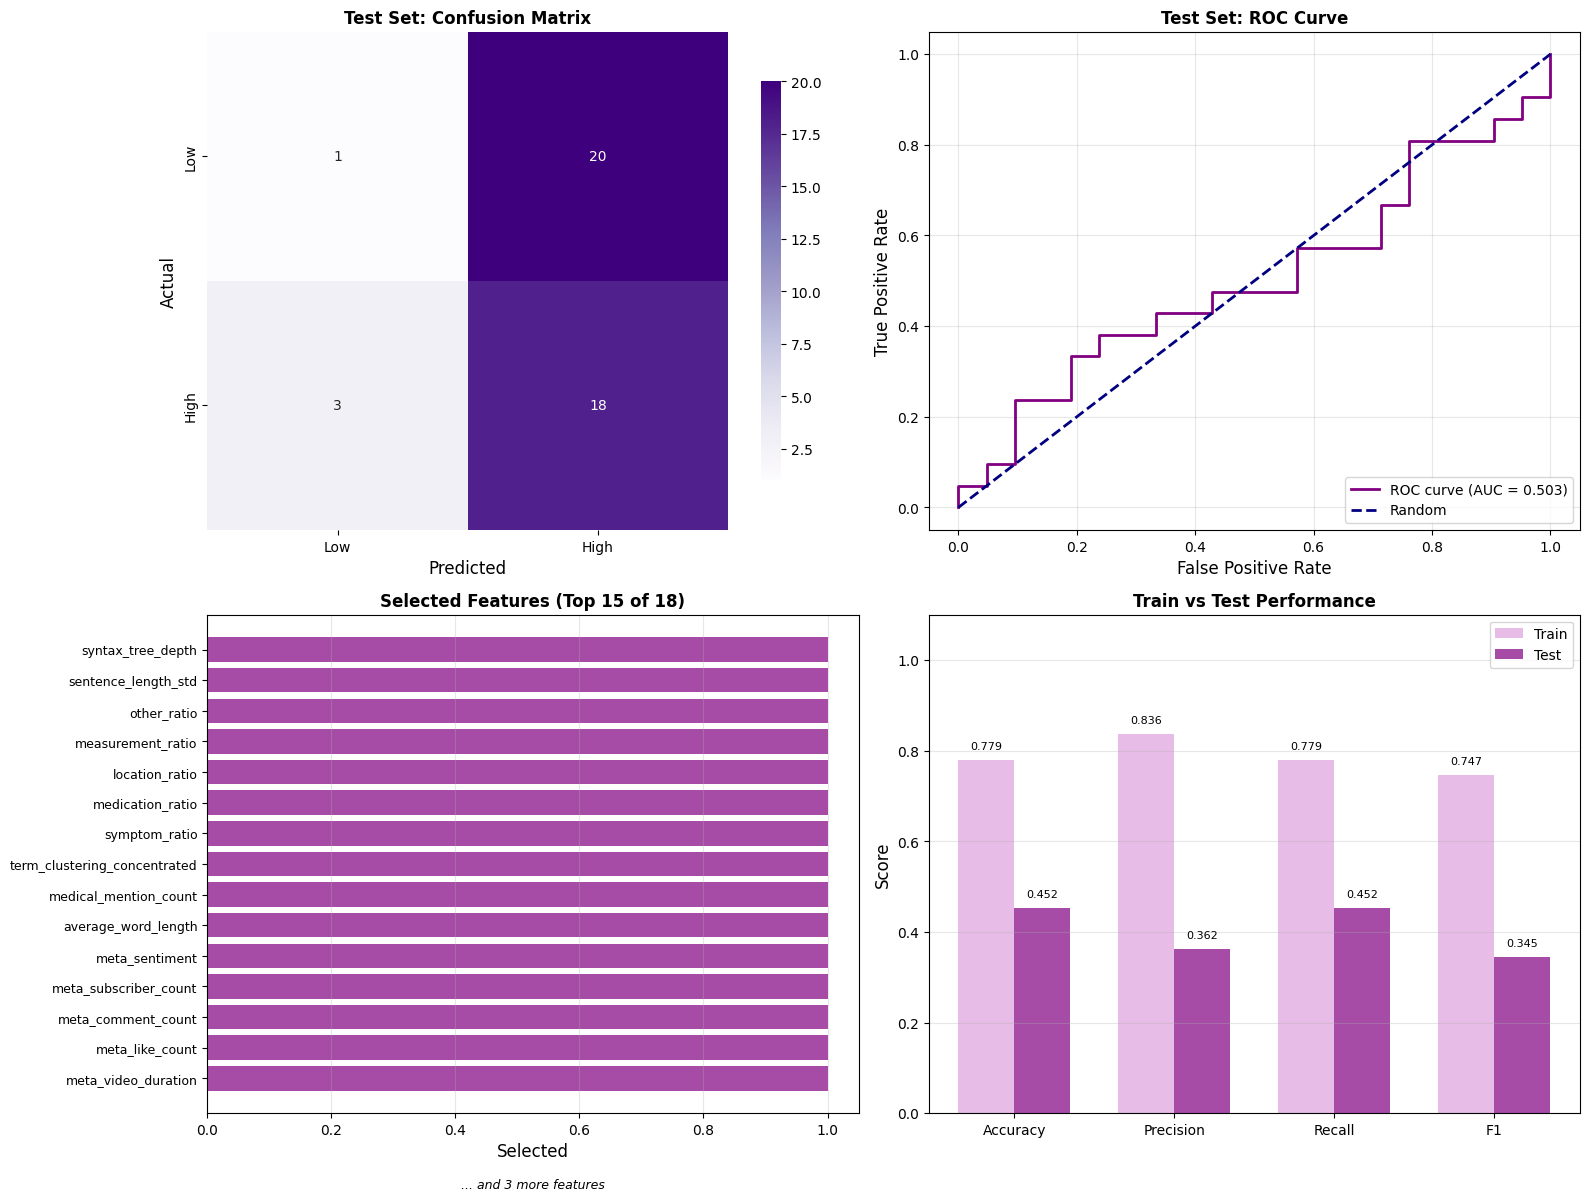


📋 All Selected Features (18):
    1. meta_video_duration
    2. meta_like_count
    3. meta_comment_count
    4. meta_subscriber_count
    5. meta_sentiment
    6. average_word_length
    7. medical_mention_count
    8. term_clustering_concentrated
    9. symptom_ratio
   10. medication_ratio
   11. location_ratio
   12. measurement_ratio
   13. other_ratio
   14. sentence_length_std
   15. syntax_tree_depth
   16. subordinate_clause_density
   17. average_dependency_distance
   18. pronoun_frequency



In [174]:

# ============================================================================
# SVM: Visualization and Detailed Analysis
# ============================================================================

print("=" * 80)
print("SVM: Visualization and Detailed Analysis")
print("=" * 80)

# Confusion Matrix
cm_test_svm = confusion_matrix(y_test_binary_aligned, y_test_pred_svm)

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(y_test_binary_aligned, y_test_pred_svm, target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test_svm, annot=True, fmt='d', cmap='Purples', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if y_test_proba_svm is not None:
    fpr_svm, tpr_svm, _ = roc_curve(y_test_binary_aligned, y_test_proba_svm)
    roc_auc_svm = auc(fpr_svm, tpr_svm)
    ax2.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_svm:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Selected Features
ax3 = axes[1, 0]
if len(selected_features_svm) > 0:
    features_to_show = selected_features_svm[:15] if len(selected_features_svm) > 15 else selected_features_svm
    ax3.barh(range(len(features_to_show)), [1] * len(features_to_show), color='purple', alpha=0.7)
    ax3.set_yticks(range(len(features_to_show)))
    ax3.set_yticklabels([f[:30] for f in features_to_show], fontsize=9)
    ax3.set_xlabel('Selected', fontsize=12)
    ax3.set_title(f'Selected Features (Top {len(features_to_show)} of {len(selected_features_svm)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    if len(selected_features_svm) > 15:
        ax3.text(0.5, -0.15, f'... and {len(selected_features_svm) - 15} more features', 
                ha='center', transform=ax3.transAxes, fontsize=9, style='italic')
else:
    ax3.text(0.5, 0.5, 'No features selected', 
            ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Selected Features', fontsize=12, fontweight='bold')

# Plot 4: Train vs Test Performance Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_metrics_svm = [train_acc_svm, train_precision_svm, train_recall_svm, train_f1_svm]
test_metrics_svm = [test_acc_svm, test_precision_svm, test_recall_svm, test_f1_svm]

x_pos = np.arange(len(metrics))
width = 0.35
ax4.bar(x_pos - width/2, train_metrics_svm, width, label='Train', color='plum', alpha=0.7)
ax4.bar(x_pos + width/2, test_metrics_svm, width, label='Test', color='purple', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_metrics_svm, test_metrics_svm)):
    ax4.text(i - width/2, train_val + 0.02, f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
    ax4.text(i + width/2, test_val + 0.02, f'{test_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features_svm)}):")
print("=" * 80)
for i, feat in enumerate(selected_features_svm, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)


In [175]:

# ============================================================================
# SAVE SVM MODEL AND RESULTS
# ============================================================================

import pickle
import json
from datetime import datetime

print("=" * 80)
print("SAVING SVM MODEL AND RESULTS")
print("=" * 80)

# Save best model
model_filename_svm = "data/best_svm_model.pkl"
with open(model_filename_svm, 'wb') as f:
    pickle.dump(best_model_svm, f)
print(f"✅ Best SVM model saved to: {model_filename_svm}")

# Get SVM info
best_svm = best_model_svm.named_steps['classification']

# Save model metadata
metadata_svm = {
    'model_name': 'SVM with Feature Selection',
    'problem_type': 'binary_classification',
    'threshold': 0.8,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'n_selected_features': len(selected_features_svm),
    'selected_features': selected_features_svm,
    'n_train_samples': X_train.shape[0],
    'n_test_samples': X_test.shape[0],
    'best_parameters': grid_search_svm.best_params_,
    'best_cv_score': float(grid_search_svm.best_score_),
    'svm_configuration': {
        'kernel': best_svm.kernel,
        'C': float(best_svm.C),
        'gamma': str(best_svm.gamma),
        'degree': int(best_svm.degree) if best_svm.kernel == 'poly' else None,
        'coef0': float(best_svm.coef0) if best_svm.kernel in ['poly', 'sigmoid'] else None,
        'class_weight': str(best_svm.class_weight) if best_svm.class_weight else None,
        'shrinking': bool(best_svm.shrinking)
    },
    'metrics': {
        'train_accuracy': float(train_acc_svm),
        'test_accuracy': float(test_acc_svm),
        'train_precision': float(train_precision_svm),
        'test_precision': float(test_precision_svm),
        'train_recall': float(train_recall_svm),
        'test_recall': float(test_recall_svm),
        'train_f1': float(train_f1_svm),
        'test_f1': float(test_f1_svm),
        'overfitting_gap': float(overfitting_gap_svm)
    }
}

if train_auc_svm is not None:
    metadata_svm['metrics']['train_auc'] = float(train_auc_svm)
if test_auc_svm is not None:
    metadata_svm['metrics']['test_auc'] = float(test_auc_svm)

if cv_train_score is not None:
    metadata_svm['cv_metrics'] = {
        'train_cv_score': float(cv_train_score),
        'test_cv_score': float(cv_test_score),
        'cv_overfitting_gap': float(cv_overfitting_gap) if cv_overfitting_gap is not None else None
    }

metadata_filename_svm = "data/best_svm_metadata.json"
with open(metadata_filename_svm, 'w') as f:
    json.dump(metadata_svm, f, indent=2)
print(f"✅ SVM model metadata saved to: {metadata_filename_svm}")

# Save selected features
selected_features_df_svm = pd.DataFrame({
    'feature_name': selected_features_svm,
    'rank': range(1, len(selected_features_svm) + 1)
})
selected_features_df_svm.to_csv('data/svm_selected_features.csv', index=False)
print(f"✅ Selected features saved to: data/svm_selected_features.csv")

print("\n" + "=" * 80)
print("SVM MODEL SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\n📝 Summary:")
print(f"   • Model file: {model_filename_svm}")
print(f"   • Metadata file: {metadata_filename_svm}")
print(f"   • Selected features: data/svm_selected_features.csv")
print(f"   • Best kernel: {best_svm.kernel}")
print(f"   • C (regularization): {best_svm.C}")
print(f"   • Gamma: {best_svm.gamma}")
print(f"   • Overfitting gap: {overfitting_gap_svm:.4f}")
print("\n💡 To load the model later:")
print(f"   import pickle")
print(f"   with open('{model_filename_svm}', 'rb') as f:")
print(f"       model = pickle.load(f)")
print("=" * 80)


SAVING SVM MODEL AND RESULTS
✅ Best SVM model saved to: data/best_svm_model.pkl
✅ SVM model metadata saved to: data/best_svm_metadata.json
✅ Selected features saved to: data/svm_selected_features.csv

SVM MODEL SAVED SUCCESSFULLY!

📝 Summary:
   • Model file: data/best_svm_model.pkl
   • Metadata file: data/best_svm_metadata.json
   • Selected features: data/svm_selected_features.csv
   • Best kernel: poly
   • C (regularization): 0.5
   • Gamma: scale
   • Overfitting gap: 0.3262

💡 To load the model later:
   import pickle
   with open('data/best_svm_model.pkl', 'rb') as f:
       model = pickle.load(f)


In [192]:
# ============================================================================
# MULTINOMIAL NAIVE BAYES: Feature Selection + Hyperparameter Tuning (Anti-Overfitting)
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# Focus on preventing overfitting with alpha (smoothing parameter)
# ============================================================================

# Import necessary modules (in case cell 0 wasn't run)
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

print("=" * 80)
print("MULTINOMIAL NAIVE BAYES: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Note: MultinomialNB requires non-negative features
# Check if data is prepared
try:
    X_train_check = X_train
    y_train_check = y_train_binary_aligned
    print("✅ Data is prepared. Proceeding with MultinomialNB optimization...")
    
    # Check for negative values (MultinomialNB requires non-negative features)
    min_val = X_train.min()
    needs_scaling = min_val < 0
    if needs_scaling:
        print(f"\n⚠️  Features contain negative values (min: {min_val:.4f})")
        print("   MultinomialNB requires non-negative features.")
        print("   Will apply MinMaxScaler in pipeline to transform features to [0, 1] range...")
    else:
        print(f"   ✅ Features are non-negative (min: {min_val:.4f})")
        print("   (MinMaxScaler will still be included in pipeline for consistency)")
        
except NameError:
    print("⚠️  WARNING: Data not prepared yet. Please run Cell 3 (DATA PREPARATION) first!")
    print("   This cell will be skipped.")
    raise

# Create pipeline with MinMaxScaler, feature selection, and MultinomialNB
# Always include MinMaxScaler to ensure non-negative features
nb_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # Always include to ensure non-negative features
    ('feature_selection', SelectKBest(f_classif)),  # Default, will be tuned
    ('classification', MultinomialNB())
])

# Parameter grid for optimization (focus on preventing overfitting)
# alpha is the key parameter for preventing overfitting (Laplace smoothing)
param_grid_nb = {
    # Feature selection method and number of features
    'feature_selection__score_func': [
        f_classif,           # F-test for classification (ANOVA F-value)
        mutual_info_classif, # Mutual information for classification
        chi2                 # Chi-squared test (requires non-negative features, which we have after MinMaxScaler)
    ],
    'feature_selection__k': [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80],  # More feature selection options
    
    # MultinomialNB hyperparameters
    'classification__alpha': [
        0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 
        0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 
        30.0, 50.0, 75.0, 100.0, 150.0, 200.0
    ],  # More granular alpha values for fine-tuning smoothing
    'classification__fit_prior': [True, False],  # Whether to learn class prior probabilities
    'classification__class_prior': [
        None,  # Learn from data
        [0.3, 0.7], [0.35, 0.65], [0.4, 0.6], [0.45, 0.55], 
        [0.5, 0.5],  # Balanced
        [0.55, 0.45], [0.6, 0.4], [0.65, 0.35], [0.7, 0.3]
    ]  # More prior probability options
}

# Stratified K-Fold for cross-validation
cv_nb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate total parameter combinations
total_combinations_nb = (len(param_grid_nb['feature_selection__k']) * 
                        len(param_grid_nb['classification__alpha']) * 
                        len(param_grid_nb['classification__fit_prior']) *
                        len(param_grid_nb['classification__class_prior']))

print(f"\n🚀 Starting GridSearchCV optimization for MultinomialNB...")
print(f"   Feature selection methods: {len(param_grid_nb['feature_selection__score_func'])} options")
print(f"     - f_classif: F-test (ANOVA) for feature selection")
print(f"     - mutual_info_classif: Mutual information for feature selection")
print(f"     - chi2: Chi-squared test for feature selection")
print(f"   Feature selection k values: {len(param_grid_nb['feature_selection__k'])} options")
print(f"   Alpha (smoothing): {len(param_grid_nb['classification__alpha'])} options")
print(f"   Fit prior: {len(param_grid_nb['classification__fit_prior'])} options")
print(f"   Class prior: {len(param_grid_nb['classification__class_prior'])} options")
print(f"   Total parameter combinations: {total_combinations_nb:,}")
print(f"   With 5-fold CV: {total_combinations_nb * 5:,} model fits")

# Time estimation
estimated_seconds = total_combinations_nb * 5 * 0.1  # NB is fast (~0.1s per fit)
estimated_minutes = estimated_seconds / 60
estimated_hours = estimated_minutes / 60

print(f"\n⏱️  Estimated Time (with parallelization):")
if estimated_hours < 1:
    print(f"   Best case: ~{estimated_minutes/2:.1f} minutes")
    print(f"   Average case: ~{estimated_minutes:.1f} minutes")
    print(f"   Worst case: ~{estimated_minutes*2:.1f} minutes")
else:
    print(f"   Best case: ~{estimated_hours/2:.2f} hours ({estimated_minutes/2:.1f} minutes)")
    print(f"   Average case: ~{estimated_hours:.2f} hours ({estimated_minutes:.1f} minutes)")
    print(f"   Worst case: ~{estimated_hours*2:.2f} hours ({estimated_minutes*2:.1f} minutes)")
print(f"\n💡 Note: MultinomialNB is fast, but with {total_combinations_nb:,} combinations,")
print(f"   this will take longer. Alpha parameter controls overfitting:")
print(f"   - Very small alpha (< 0.01): Minimal smoothing, high risk of overfitting")
print(f"   - Small alpha (0.01-0.1): Less smoothing, may overfit")
print(f"   - Medium alpha (0.1-1.0): Moderate smoothing, balanced")
print(f"   - Large alpha (1.0-10.0): More smoothing, prevents overfitting")
print(f"   - Very large alpha (> 10.0): Heavy smoothing, may underfit")
print("=" * 80)

# Grid search
print("\n📊 Starting optimization...")
print("   (This should be relatively fast. Progress will be shown below.)\n")

start_time_nb = time.time()

grid_search_nb = GridSearchCV(
    nb_pipeline,
    param_grid_nb,
    cv=cv_nb,
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPUs
    verbose=1,  # Show progress
    return_train_score=True  # Return training scores for overfitting check
)

# Fit grid search (MinMaxScaler is already in the pipeline)
grid_search_nb.fit(X_train, y_train_binary_aligned)

elapsed_time_nb = time.time() - start_time_nb

print(f"\n✅ Optimization completed!")
print(f"   Total time: {elapsed_time_nb/60:.1f} minutes ({elapsed_time_nb:.1f} seconds)")

# Get best parameters from GridSearchCV
best_params_nb = grid_search_nb.best_params_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and CV score
print(f"\n🏆 Best Parameters (from GridSearchCV):")
for param, value in best_params_nb.items():
    if param == 'feature_selection__score_func':
        # Display function name instead of function object
        func_name = value.__name__ if hasattr(value, '__name__') else str(value)
        print(f"   {param}: {func_name}")
    else:
        print(f"   {param}: {value}")

print(f"\n📊 Best CV Score: {grid_search_nb.best_score_:.4f}")

# ============================================================================
# RETRAIN ON FULL TRAINING SET WITH BEST PARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

print("\n🔄 Retraining model on FULL training set with best parameters...")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Features: {X_train.shape[1]}")

# Create a new pipeline with best parameters (MinMaxScaler is always included)
# Use the best feature selection method from grid search
best_score_func = best_params_nb['feature_selection__score_func']
best_pipeline_nb = Pipeline([
    ('scaler', MinMaxScaler()),  # Always include to ensure non-negative features
    ('feature_selection', SelectKBest(score_func=best_score_func, k=best_params_nb['feature_selection__k'])),
    ('classification', MultinomialNB(
        alpha=best_params_nb['classification__alpha'],
        fit_prior=best_params_nb['classification__fit_prior'],
        class_prior=best_params_nb['classification__class_prior']
    ))
])

# Retrain on FULL training set
best_pipeline_nb.fit(X_train, y_train_binary_aligned)

# Use this as the final model
best_model_nb = best_pipeline_nb

print("✅ Model retrained on FULL training set!")
print("=" * 80)

# Get selected features
selected_features_mask_nb = best_model_nb.named_steps['feature_selection'].get_support()
selected_features_nb = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask_nb[i]]
n_selected_features_nb = len(selected_features_nb)

print(f"\n📋 Selected Features: {n_selected_features_nb} out of {len(feature_names)}")

# Display NB info
best_nb = best_model_nb.named_steps['classification']
best_feature_selector = best_model_nb.named_steps['feature_selection']
print(f"\n🔧 MultinomialNB Configuration:")
print(f"   Feature selection method: {best_score_func.__name__}")
print(f"   Number of selected features: {best_params_nb['feature_selection__k']}")
print(f"   Alpha (smoothing): {best_nb.alpha}")
print(f"   Fit prior: {best_nb.fit_prior}")
if best_nb.class_prior is not None:
    print(f"   Class prior: {best_nb.class_prior}")
else:
    print(f"   Class prior: Learned from data")

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

print(f"\n📊 Test Set Information:")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Features: {X_test.shape[1]}")

# ============================================================================
# FINAL EVALUATION: Make predictions on test set
# ============================================================================
print("\n🔍 Making predictions on test set with retrained model...")

# Make predictions on training set (for comparison)
y_train_pred_nb = best_model_nb.predict(X_train)

# Make predictions on TEST SET (final evaluation)
y_test_pred_nb = best_model_nb.predict(X_test)

print("✅ Predictions completed!")
print(f"   Training predictions: {len(y_train_pred_nb)} samples")
print(f"   Test predictions: {len(y_test_pred_nb)} samples")

# Get probabilities for AUC
try:
    y_train_proba_nb = best_model_nb.predict_proba(X_train)[:, 1]
    y_test_proba_nb = best_model_nb.predict_proba(X_test)[:, 1]
    train_auc_nb = roc_auc_score(y_train_binary_aligned, y_train_proba_nb)
    test_auc_nb = roc_auc_score(y_test_binary_aligned, y_test_proba_nb)
except:
    train_auc_nb = None
    test_auc_nb = None

# Calculate all metrics
train_acc_nb = accuracy_score(y_train_binary_aligned, y_train_pred_nb)
test_acc_nb = accuracy_score(y_test_binary_aligned, y_test_pred_nb)
train_precision_nb = precision_score(y_train_binary_aligned, y_train_pred_nb, average='weighted', zero_division=0)
test_precision_nb = precision_score(y_test_binary_aligned, y_test_pred_nb, average='weighted', zero_division=0)
train_recall_nb = recall_score(y_train_binary_aligned, y_train_pred_nb, average='weighted', zero_division=0)
test_recall_nb = recall_score(y_test_binary_aligned, y_test_pred_nb, average='weighted', zero_division=0)
train_f1_nb = f1_score(y_train_binary_aligned, y_train_pred_nb, average='weighted', zero_division=0)
test_f1_nb = f1_score(y_test_binary_aligned, y_test_pred_nb, average='weighted', zero_division=0)

# Check for overfitting (difference between train and test accuracy)
overfitting_gap_nb = train_acc_nb - test_acc_nb

# Check train vs test scores from CV
if 'mean_train_score' in grid_search_nb.cv_results_:
    mean_train_scores = grid_search_nb.cv_results_['mean_train_score']
    mean_test_scores = grid_search_nb.cv_results_['mean_test_score']
    best_idx = grid_search_nb.best_index_
    cv_train_score = mean_train_scores[best_idx]
    cv_test_score = mean_test_scores[best_idx]
    cv_overfitting_gap_nb = cv_train_score - cv_test_score
else:
    cv_train_score = None
    cv_test_score = None
    cv_overfitting_gap_nb = None

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 Cross-Validation Performance:")
print(f"   Train CV Score: {cv_train_score:.4f}" if cv_train_score is not None else "   Train CV Score: N/A")
print(f"   Test CV Score: {grid_search_nb.best_score_:.4f}")
if cv_overfitting_gap_nb is not None:
    print(f"   CV Overfitting Gap: {cv_overfitting_gap_nb:.4f}")
    if cv_overfitting_gap_nb > 0.15:
        print(f"   ⚠️  WARNING: Large CV gap detected! Model may be overfitting.")
    elif cv_overfitting_gap_nb > 0.10:
        print(f"   ⚠️  CAUTION: Moderate CV gap detected.")
    else:
        print(f"   ✅ Good: CV gap is acceptable.")

print(f"\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_acc_nb:.4f}")
print(f"   Precision: {train_precision_nb:.4f}")
print(f"   Recall:    {train_recall_nb:.4f}")
print(f"   F1 Score:  {train_f1_nb:.4f}")
if train_auc_nb is not None:
    print(f"   AUC-ROC:   {train_auc_nb:.4f}")

print(f"\n📊 Test Set Performance (FINAL EVALUATION):")
print(f"   ✅ Final Test Accuracy:  {test_acc_nb:.4f}")
print(f"   ✅ Final Test Precision: {test_precision_nb:.4f}")
print(f"   ✅ Final Test Recall:    {test_recall_nb:.4f}")
print(f"   ✅ Final Test F1 Score:  {test_f1_nb:.4f}")
if test_auc_nb is not None:
    print(f"   ✅ Final Test AUC-ROC:   {test_auc_nb:.4f}")
print(f"\n   📝 Note: This is the performance on the test set using the model")
print(f"      trained on the FULL training set with best parameters.")

print(f"\n⚠️  Overfitting Check (Train vs Test):")
print(f"   Train-Test Accuracy Gap: {overfitting_gap_nb:.4f}")
if overfitting_gap_nb > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    print(f"   💡 Consider increasing alpha (smoothing parameter) to reduce overfitting.")
elif overfitting_gap_nb > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
    print(f"   💡 Consider slightly increasing alpha if gap increases.")
else:
    print(f"   ✅ Good: Gap is acceptable.")
    print(f"   💡 Current alpha ({best_nb.alpha}) provides good regularization.")

print("\n" + "=" * 80)


MULTINOMIAL NAIVE BAYES: Feature Selection + Hyperparameter Tuning
✅ Data is prepared. Proceeding with MultinomialNB optimization...

⚠️  Features contain negative values (min: -2.3436)
   MultinomialNB requires non-negative features.
   Will apply MinMaxScaler in pipeline to transform features to [0, 1] range...

🚀 Starting GridSearchCV optimization for MultinomialNB...
   Feature selection methods: 3 options
     - f_classif: F-test (ANOVA) for feature selection
     - mutual_info_classif: Mutual information for feature selection
     - chi2: Chi-squared test for feature selection
   Feature selection k values: 12 options
   Alpha (smoothing): 29 options
   Fit prior: 2 options
   Class prior: 10 options
   Total parameter combinations: 6,960
   With 5-fold CV: 34,800 model fits

⏱️  Estimated Time (with parallelization):
   Best case: ~29.0 minutes
   Average case: ~58.0 minutes
   Worst case: ~116.0 minutes

💡 Note: MultinomialNB is fast, but with 6,960 combinations,
   this will t


✅ Optimization completed!
   Total time: 2.3 minutes (137.2 seconds)

OPTIMIZATION COMPLETE!

🏆 Best Parameters (from GridSearchCV):
   classification__alpha: 0.7
   classification__class_prior: [0.45, 0.55]
   classification__fit_prior: False
   feature_selection__k: 20
   feature_selection__score_func: mutual_info_classif

📊 Best CV Score: 0.6571

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Retraining model on FULL training set with best parameters...
   Training samples: 140
   Features: 31
✅ Model retrained on FULL training set!

📋 Selected Features: 20 out of 31

🔧 MultinomialNB Configuration:
   Feature selection method: mutual_info_classif
   Number of selected features: 20
   Alpha (smoothing): 0.7
   Fit prior: False
   Class prior: [0.45, 0.55]

EVALUATING ON TEST SET

📊 Test Set Information:
   Test samples: 42
   Features: 31

🔍 Making predictions on test set with retrained model...
✅ Predictions completed!
   Training predictions: 140 samples
   Test predictio

MULTINOMIAL NB: Visualization and Detailed Analysis

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.56      0.24      0.33        21
        High       0.52      0.81      0.63        21

    accuracy                           0.52        42
   macro avg       0.54      0.52      0.48        42
weighted avg       0.54      0.52      0.48        42



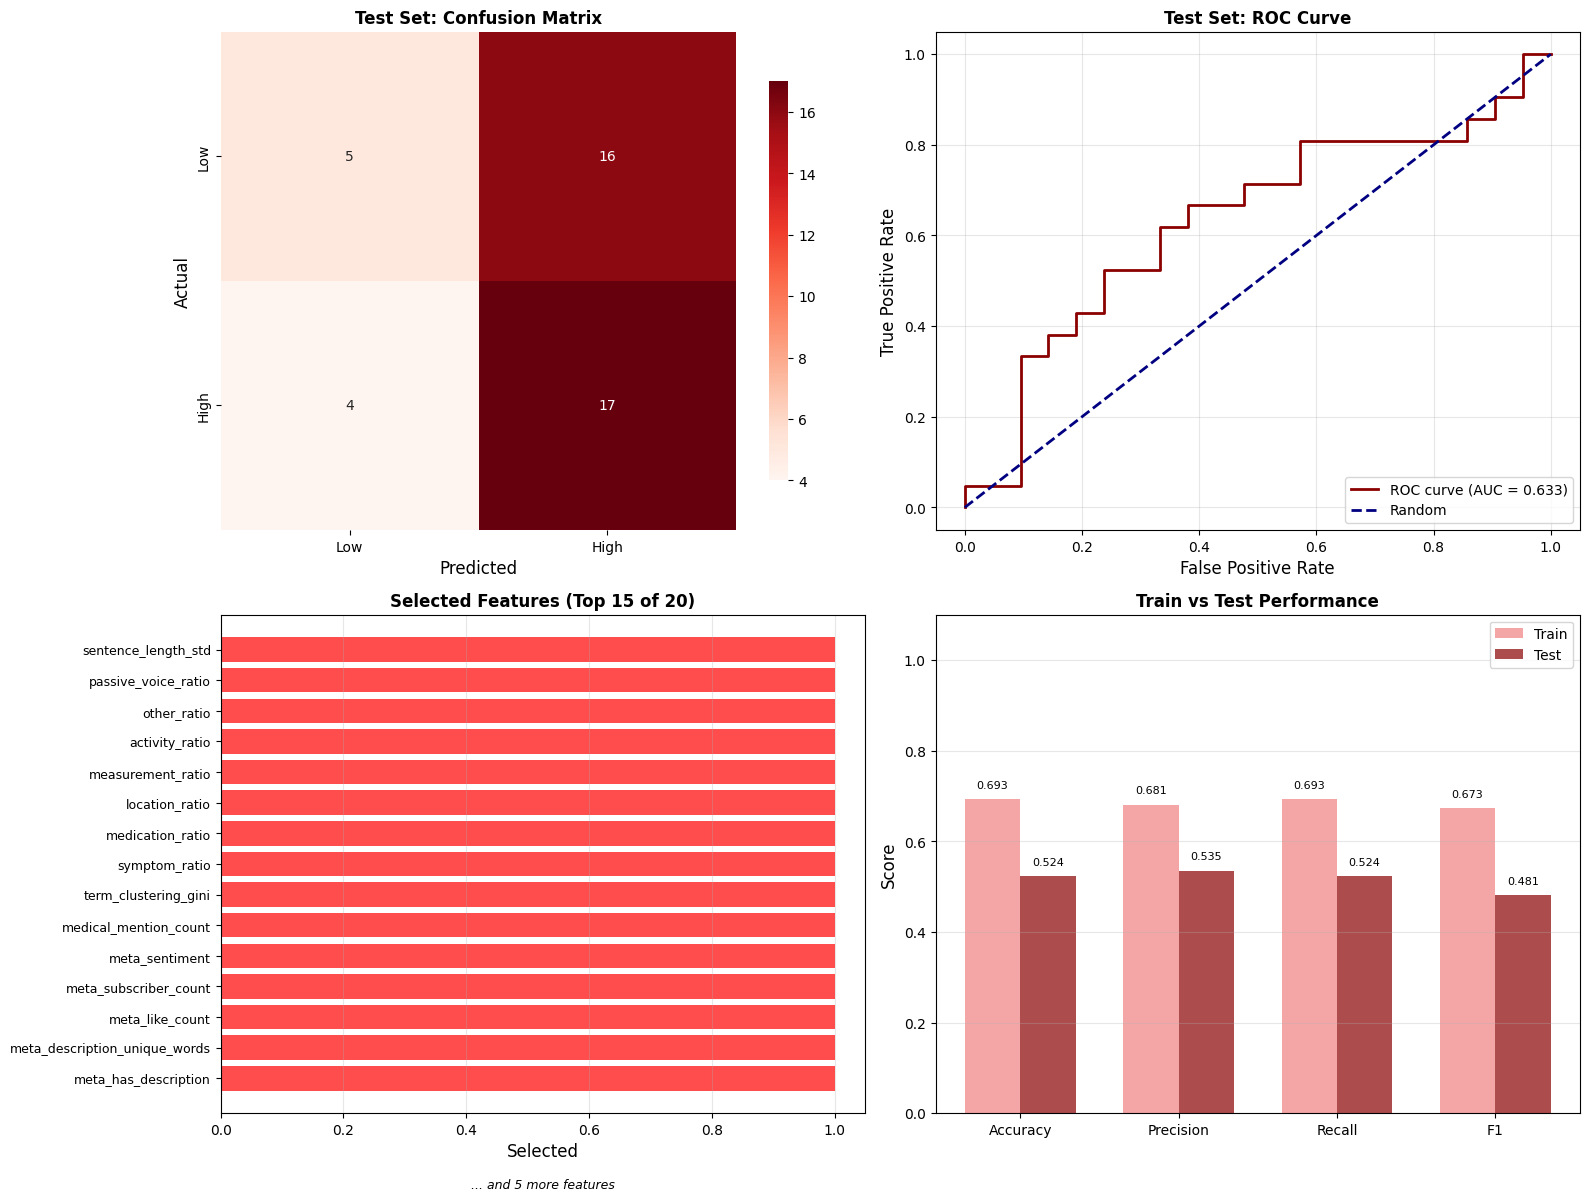


📋 All Selected Features (20):
    1. meta_has_description
    2. meta_description_unique_words
    3. meta_like_count
    4. meta_subscriber_count
    5. meta_sentiment
    6. medical_mention_count
    7. term_clustering_gini
    8. symptom_ratio
    9. medication_ratio
   10. location_ratio
   11. measurement_ratio
   12. activity_ratio
   13. other_ratio
   14. passive_voice_ratio
   15. sentence_length_std
   16. syntax_tree_depth
   17. subordinate_clause_density
   18. average_dependency_distance
   19. pronoun_frequency
   20. word_count



In [193]:
# ============================================================================
# MULTINOMIAL NB: Visualization and Detailed Analysis
# ============================================================================

print("=" * 80)
print("MULTINOMIAL NB: Visualization and Detailed Analysis")
print("=" * 80)

# Confusion Matrix
cm_test_nb = confusion_matrix(y_test_binary_aligned, y_test_pred_nb)

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(y_test_binary_aligned, y_test_pred_nb, target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test_nb, annot=True, fmt='d', cmap='Reds', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if y_test_proba_nb is not None:
    fpr_nb, tpr_nb, _ = roc_curve(y_test_binary_aligned, y_test_proba_nb)
    roc_auc_nb = auc(fpr_nb, tpr_nb)
    ax2.plot(fpr_nb, tpr_nb, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc_nb:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Selected Features
ax3 = axes[1, 0]
if len(selected_features_nb) > 0:
    features_to_show = selected_features_nb[:15] if len(selected_features_nb) > 15 else selected_features_nb
    ax3.barh(range(len(features_to_show)), [1] * len(features_to_show), color='red', alpha=0.7)
    ax3.set_yticks(range(len(features_to_show)))
    ax3.set_yticklabels([f[:30] for f in features_to_show], fontsize=9)
    ax3.set_xlabel('Selected', fontsize=12)
    ax3.set_title(f'Selected Features (Top {len(features_to_show)} of {len(selected_features_nb)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    if len(selected_features_nb) > 15:
        ax3.text(0.5, -0.15, f'... and {len(selected_features_nb) - 15} more features', 
                ha='center', transform=ax3.transAxes, fontsize=9, style='italic')
else:
    ax3.text(0.5, 0.5, 'No features selected', 
            ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Selected Features', fontsize=12, fontweight='bold')

# Plot 4: Train vs Test Performance Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_metrics_nb = [train_acc_nb, train_precision_nb, train_recall_nb, train_f1_nb]
test_metrics_nb = [test_acc_nb, test_precision_nb, test_recall_nb, test_f1_nb]

x_pos = np.arange(len(metrics))
width = 0.35
ax4.bar(x_pos - width/2, train_metrics_nb, width, label='Train', color='lightcoral', alpha=0.7)
ax4.bar(x_pos + width/2, test_metrics_nb, width, label='Test', color='darkred', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_metrics_nb, test_metrics_nb)):
    ax4.text(i - width/2, train_val + 0.02, f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
    ax4.text(i + width/2, test_val + 0.02, f'{test_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features_nb)}):")
print("=" * 80)
for i, feat in enumerate(selected_features_nb, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)


In [194]:
# ============================================================================
# SAVE MULTINOMIAL NB MODEL AND RESULTS
# ============================================================================

import pickle
import json
from datetime import datetime

print("=" * 80)
print("SAVING MULTINOMIAL NB MODEL AND RESULTS")
print("=" * 80)

# Verify that best_model_nb is the retrained model
print("\n🔍 Verifying model to save...")
if hasattr(best_model_nb, 'named_steps'):
    print("✅ Model is a Pipeline (retrained model)")
    print(f"   Model type: {type(best_model_nb).__name__}")
    print(f"   This model was trained on FULL training set ({X_train.shape[0]} samples)")
else:
    print("⚠️  WARNING: Model structure unexpected")

# Save best model (this is the model retrained on FULL training set)
model_filename_nb = "data/best_multinomial_nb_model.pkl"
with open(model_filename_nb, 'wb') as f:
    pickle.dump(best_model_nb, f)
print(f"\n✅ Best MultinomialNB model saved to: {model_filename_nb}")
print(f"   📝 Note: This model was trained on FULL training set with best parameters")

# Get NB info
best_nb = best_model_nb.named_steps['classification']

# Ensure best_params_nb exists
if 'best_params_nb' not in locals():
    try:
        best_params_nb = grid_search_nb.best_params_
        print("⚠️  Note: Using best_params from grid_search_nb (retraining cell may not have been run)")
    except NameError:
        print("⚠️  ERROR: best_params_nb not found. Please run the MultinomialNB training cell first!")
        raise

# Save model metadata
metadata_nb = {
    'model_name': 'Multinomial Naive Bayes with Feature Selection',
    'problem_type': 'binary_classification',
    'threshold': 0.8,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'n_selected_features': len(selected_features_nb),
    'selected_features': selected_features_nb,
    'n_train_samples': X_train.shape[0],
    'n_test_samples': X_test.shape[0],
    'best_parameters': best_params_nb,
    'best_cv_score': float(grid_search_nb.best_score_),
    'training_note': 'Model was retrained on FULL training set with best parameters from GridSearchCV',
    'nb_configuration': {
        'alpha': float(best_nb.alpha),
        'fit_prior': bool(best_nb.fit_prior),
        'class_prior': best_nb.class_prior.tolist() if best_nb.class_prior is not None else None
    },
    'metrics': {
        'train_accuracy': float(train_acc_nb),
        'test_accuracy': float(test_acc_nb),
        'train_precision': float(train_precision_nb),
        'test_precision': float(test_precision_nb),
        'train_recall': float(train_recall_nb),
        'test_recall': float(test_recall_nb),
        'train_f1': float(train_f1_nb),
        'test_f1': float(test_f1_nb),
        'overfitting_gap': float(overfitting_gap_nb)
    }
}

if train_auc_nb is not None:
    metadata_nb['metrics']['train_auc'] = float(train_auc_nb)
if test_auc_nb is not None:
    metadata_nb['metrics']['test_auc'] = float(test_auc_nb)

if cv_train_score is not None:
    metadata_nb['cv_metrics'] = {
        'train_cv_score': float(cv_train_score),
        'test_cv_score': float(cv_test_score),
        'cv_overfitting_gap': float(cv_overfitting_gap_nb) if cv_overfitting_gap_nb is not None else None
    }

metadata_filename_nb = "data/best_multinomial_nb_metadata.json"
with open(metadata_filename_nb, 'w') as f:
    json.dump(metadata_nb, f, indent=2)
print(f"✅ MultinomialNB model metadata saved to: {metadata_filename_nb}")

# Save selected features
selected_features_df_nb = pd.DataFrame({
    'feature_name': selected_features_nb,
    'rank': range(1, len(selected_features_nb) + 1)
})
selected_features_df_nb.to_csv('data/multinomial_nb_selected_features.csv', index=False)
print(f"✅ Selected features saved to: data/multinomial_nb_selected_features.csv")

print("\n" + "=" * 80)
print("MULTINOMIAL NB MODEL SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\n📝 Summary:")
print(f"   • Model file: {model_filename_nb}")
print(f"   • Metadata file: {metadata_filename_nb}")
print(f"   • Selected features: data/multinomial_nb_selected_features.csv")
print(f"   • Alpha (smoothing): {best_nb.alpha}")
print(f"   • Fit prior: {best_nb.fit_prior}")
print(f"   • Overfitting gap: {overfitting_gap_nb:.4f}")
print("\n💡 To load the model later:")
print(f"   import pickle")
print(f"   with open('{model_filename_nb}', 'rb') as f:")
print(f"       model = pickle.load(f)")
print("=" * 80)


SAVING MULTINOMIAL NB MODEL AND RESULTS

🔍 Verifying model to save...
✅ Model is a Pipeline (retrained model)
   Model type: Pipeline
   This model was trained on FULL training set (140 samples)

✅ Best MultinomialNB model saved to: data/best_multinomial_nb_model.pkl
   📝 Note: This model was trained on FULL training set with best parameters


AttributeError: 'list' object has no attribute 'tolist'